# AprioriTid Algorithm
Model untuk Frequent Pattern Mining dengan Transaction ID encoding

## Cell 1: Import Libraries & AprioriTid Implementation

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

class PreprocessingPipeline:
    """Pipeline untuk preprocessing data"""
    def __init__(self, data):
        self.data = data.copy()
        self.label_encoders = {}
        self.scaler = StandardScaler()
        self.imputer = SimpleImputer(strategy='mean')
    
    def handle_missing_values(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        if len(numeric_cols) > 0:
            self.data[numeric_cols] = self.imputer.fit_transform(self.data[numeric_cols])
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            self.data[col].fillna(self.data[col].mode()[0] if len(self.data[col].mode()) > 0 else 'Unknown', inplace=True)
        print("✓ Handle Missing Values: Selesai")
        return self
    
    def handle_outliers(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        outlier_count = 0
        for col in numeric_cols:
            Q1 = self.data[col].quantile(0.25)
            Q3 = self.data[col].quantile(0.75)
            IQR = Q3 - Q1
            mask = (self.data[col] >= Q1 - 1.5 * IQR) & (self.data[col] <= Q3 + 1.5 * IQR)
            outlier_count += (~mask).sum()
            self.data = self.data[mask]
        print(f"✓ Handle Outliers: Dihapus {outlier_count} data outlier")
        return self
    
    def label_encoding(self):
        categorical_cols = self.data.select_dtypes(include=['object']).columns
        for col in categorical_cols:
            le = LabelEncoder()
            self.data[col] = le.fit_transform(self.data[col])
            self.label_encoders[col] = le
        print(f"✓ Label Encoding: {len(categorical_cols)} fitur categorical di-encode")
        return self
    
    def normalize(self):
        numeric_cols = self.data.select_dtypes(include=[np.number]).columns
        for col in numeric_cols:
            mean = self.data[col].mean()
            std = self.data[col].std()
            if std != 0:
                self.data[col] = (self.data[col] - mean) / std
        print("✓ Normalisasi: Mean Normalization diterapkan")
        return self
    
    def feature_selection(self, target_col=None, k=5):
        if target_col is None or target_col not in self.data.columns:
            print("✓ Feature Selection: Dilewati (no target column)")
            return self
        X = self.data.drop(columns=[target_col])
        y = self.data[target_col]
        if len(X.columns) > k:
            selector = SelectKBest(f_classif, k=k)
            selector.fit(X, y)
            selected_features = X.columns[selector.get_support()].tolist()
            self.data = self.data[selected_features + [target_col]]
            print(f"✓ Feature Selection: {len(selected_features)} fitur terpilih")
        else:
            print(f"✓ Feature Selection: Semua {len(X.columns)} fitur dipertahankan")
        return self
    
    def get_data(self):
        return self.data


class AprioriTidModel:
    """AprioriTid Algorithm - Frequent Pattern Mining dengan Transaction ID.

    Confidence dihitung dari TID intersection aktual:
        confidence(A → B) = |TID(A) ∩ TID(B)| / |TID(A)|
    """

    def __init__(self, min_support=0.2, min_confidence=0.5):
        self.min_support       = min_support
        self.min_confidence    = min_confidence
        self.frequent_patterns = {}   # k → {frozenset: [TID list]}
        self.tidsets           = {}   # item → set of TIDs (1-itemset)
        self.rules             = []   # association rules dengan confidence dari data
        self.min_support_count = 0
        self._n                = 0

    def prepare_transactions(self, df):
        """Konversi dataframe menjadi dict TID: {item: set_of_TIDs}."""
        df_discrete = df.copy()
        # Diskretisasi: numerik → _H (≥ median) / _L (< median)
        medians = {col: df_discrete[col].median()
                   for col in df_discrete.columns
                   if pd.api.types.is_numeric_dtype(df_discrete[col])}
        for col in df_discrete.columns:
            if col in medians:
                df_discrete[col] = df_discrete[col].apply(
                    lambda x: f"{col}_H" if x >= medians[col] else f"{col}_L")
            else:
                df_discrete[col] = df_discrete[col].astype(str).apply(lambda x: f"{col}_{x}")

        # TID lists per item
        item_tids = {}
        for tid, (_, row) in enumerate(df_discrete.iterrows()):
            for item in row.values:
                item = str(item)
                if item not in item_tids:
                    item_tids[item] = []
                item_tids[item].append(tid)
        return item_tids, df_discrete

    def fit(self, df, target_col=None):
        n = len(df)
        self._n = n
        self.min_support_count = int(np.ceil(self.min_support * n))

        item_tids, _ = self.prepare_transactions(df)

        # Frequent 1-itemsets
        L1 = {frozenset([item]): set(tids)
              for item, tids in item_tids.items()
              if len(tids) >= self.min_support_count}
        self.frequent_patterns[1] = {k: list(v) for k, v in L1.items()}
        self.tidsets = {list(k)[0]: v for k, v in L1.items()}

        # k-itemsets via TID intersection
        k = 2
        Lk_prev = L1
        while Lk_prev and k <= min(5, len(df.columns)):
            Lk = {}
            keys = list(Lk_prev.keys())
            for i in range(len(keys)):
                for j in range(i + 1, len(keys)):
                    union = keys[i] | keys[j]
                    if len(union) == k:
                        inter = Lk_prev[keys[i]] & Lk_prev[keys[j]]
                        if len(inter) >= self.min_support_count:
                            Lk[union] = inter
            if Lk:
                self.frequent_patterns[k] = {kk: list(vv) for kk, vv in Lk.items()}
            Lk_prev = Lk
            k += 1

        # Generate association rules dari 2-itemsets menggunakan TID intersection
        self.rules = []
        if 2 in self.frequent_patterns:
            for itemset, tids in self.frequent_patterns[2].items():
                items = list(itemset)
                pair_count = len(tids)
                support = round(pair_count / n, 4)
                # A → B
                a, b = items[0], items[1]
                tid_a = self.tidsets.get(a, set())
                tid_b = self.tidsets.get(b, set())
                for ant, cons, tid_ant in [(a, b, tid_a), (b, a, tid_b)]:
                    cnt_ant = len(tid_ant)
                    if cnt_ant == 0:
                        continue
                    conf = round(pair_count / cnt_ant, 4)
                    if conf >= self.min_confidence:
                        cons_sup = len(self.tidsets.get(cons, set())) / n
                        self.rules.append({
                            'antecedent': ant,
                            'consequent': cons,
                            'support': support,
                            'confidence': conf,
                            'lift': round(conf / cons_sup, 4) if cons_sup > 0 else 1.0,
                            'tid_count': pair_count,
                        })
        return self

    def get_summary(self):
        """Dapatkan ringkasan hasil"""
        total_patterns = sum(len(v) for v in self.frequent_patterns.values())
        avg_conf = round(float(np.mean([r['confidence'] for r in self.rules])), 4) if self.rules else 0
        return {
            'total_patterns': total_patterns,
            'patterns_by_level': {k: len(v) for k, v in self.frequent_patterns.items()},
            'total_rules': len(self.rules),
            'avg_confidence': avg_conf,
        }


def run_aprioritid_analysis(data_path, dataset_name, target_col=None):
    """Main function untuk menjalankan AprioriTid analysis"""
    print(f"\n{'='*60}")
    print(f"APRIORITID ANALYSIS: {dataset_name}")
    print(f"{'='*60}")

    df = pd.read_csv(data_path)
    print(f"\n📊 Data Shape: {df.shape}")
    print(f"Kolom: {df.columns.tolist()}")

    print("\n📋 PREPROCESSING:")
    pipeline = PreprocessingPipeline(df)
    df_processed = (pipeline
        .handle_missing_values()
        .normalize()
        .label_encoding()
        .handle_outliers()
        .feature_selection(target_col, k=8)
        .get_data())

    print(f"\n✓ Data setelah preprocessing: {df_processed.shape}")

    print("\n🔍 APRIORITID MODEL:")
    model = AprioriTidModel(min_support=0.2, min_confidence=0.5)
    model.fit(df_processed, target_col)

    summary = model.get_summary()
    print(f"✓ Total Frequent Patterns: {summary['total_patterns']}")
    print(f"  Pattern Distribution by Level: {summary['patterns_by_level']}")
    print(f"✓ Total Rules (dari TID): {summary['total_rules']}")
    print(f"✓ Avg Confidence: {summary['avg_confidence']:.4f}")

    if len(summary['patterns_by_level']) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        levels = list(summary['patterns_by_level'].keys())
        counts = list(summary['patterns_by_level'].values())

        axes[0].bar(levels, counts, color='steelblue', edgecolor='black')
        axes[0].set_xlabel('Pattern Level (k-itemset)')
        axes[0].set_ylabel('Count')
        axes[0].set_title(f'Frequent Patterns Distribution - {dataset_name}')
        axes[0].grid(True, alpha=0.3, axis='y')

        cumulative = np.cumsum(counts)
        axes[1].plot(levels, cumulative, marker='o', linewidth=2, markersize=8, color='darkgreen')
        axes[1].fill_between(levels, cumulative, alpha=0.3, color='lightgreen')
        axes[1].set_xlabel('Pattern Level (k-itemset)')
        axes[1].set_ylabel('Cumulative Count')
        axes[1].set_title(f'Cumulative Patterns - {dataset_name}')
        axes[1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    if model.rules:
        top_rules = sorted(model.rules, key=lambda x: x['confidence'], reverse=True)[:5]
        print("\n📈 Top 5 Rules (dari TID intersection):")
        for i, r in enumerate(top_rules, 1):
            print(f"{i}. {r['antecedent']} => {r['consequent']}")
            print(f"   Support: {r['support']:.4f}, Confidence: {r['confidence']:.4f}, Lift: {r['lift']:.4f}, TID count: {r['tid_count']}")

    return model, df_processed

print("✓ AprioriTid Model berhasil di-initialize")


✓ AprioriTid Model berhasil di-initialize


In [43]:

# ─── Helper: diskretisasi target numerik ────────────────────
NUMERIC_TARGET_COLS = {'Yield(tons)', 'Crop_Yield', 'Value From', 'Value To'}

def discretize_numeric_target(df, target_col):
    if target_col not in df.columns:
        return df
    if not pd.api.types.is_numeric_dtype(df[target_col]):
        return df
    df = df.copy()
    try:
        df[target_col] = pd.qcut(
            df[target_col], q=3, labels=['Low','Medium','High'], duplicates='drop'
        ).astype(str)
    except Exception:
        df[target_col] = pd.cut(
            df[target_col], bins=3, labels=['Low','Medium','High']
        ).astype(str)
    print(f"\u2713 Target '{target_col}' didiskretisasi \u2192 Low/Medium/High")
    return df
# ─────────────────────────────────────────────────────────────


## Cell 2: Dataset1 - Rice Leaf Diseases

In [44]:
import os
from PIL import Image

def extract_image_features(image_path, size=(32, 32)):
    """Extract basic features dari image"""
    try:
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(size)
        img_array = np.array(img_resized)
        
        r_mean = img_array[:,:,0].mean()
        g_mean = img_array[:,:,1].mean()
        b_mean = img_array[:,:,2].mean()
        r_std = img_array[:,:,0].std()
        g_std = img_array[:,:,1].std()
        b_std = img_array[:,:,2].std()
        
        return [r_mean, g_mean, b_mean, r_std, g_std, b_std]
    except:
        return [0, 0, 0, 0, 0, 0]

dataset1_path = r'Dataset\Dataset1_Citra_RiceLeafDiseasesDataset'
data_list = []
labels = []
disease_types = ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']

if os.path.exists(dataset1_path):
    for disease in disease_types:
        disease_path = os.path.join(dataset1_path, disease)
        if os.path.exists(disease_path):
            image_files = [f for f in os.listdir(disease_path) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
            
            for img_file in image_files:
                try:
                    img_full_path = os.path.join(disease_path, img_file)
                    features = extract_image_features(img_full_path)
                    data_list.append(features)
                    labels.append(disease)
                except:
                    pass
    
    if len(data_list) > 0:
        df_rice = pd.DataFrame(data_list, columns=['R_mean', 'G_mean', 'B_mean', 'R_std', 'G_std', 'B_std'])
        df_rice['Disease'] = labels
        
        print(f"\n{'='*60}")
        print(f"APRIORUTID ANALYSIS: Rice Leaf Diseases")
        print(f"{'='*60}")
        print(f"✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: {df_rice.shape}")
        print(f"Disease distribution: {df_rice['Disease'].value_counts().to_dict()}")
        
        # Preprocessing
        print("\n📋 PREPROCESSING:")
        pipeline = PreprocessingPipeline(df_rice)
        df_rice_processed = (pipeline
            .handle_missing_values()
            .normalize()
            .label_encoding()
            .handle_outliers()
            .feature_selection('Disease', k=5)
            .get_data())
        
        print(f"✓ Data setelah preprocessing: {df_rice_processed.shape}")
        
        # Run AprioriTid
        print("\n🔍 APRIORUTID MODEL:")
        model_rice = AprioriTidModel(min_support=0.2)
        model_rice.fit(df_rice_processed)
        
        summary_rice = model_rice.get_summary()
        print(f"✓ Total Patterns: {summary_rice['total_patterns']}")
        print(f"✓ Patterns by Level: {summary_rice['patterns_by_level']}")
        
        data_rice = df_rice_processed
    else:
        print("⚠️ Tidak ada gambar yang dapat diproses dari Dataset1")
        model_rice = None
        data_rice = None
else:
    print(f"⚠️ Path tidak ditemukan: {dataset1_path}")
    model_rice = None
    data_rice = None



APRIORUTID ANALYSIS: Rice Leaf Diseases
✓ Dataset1 (Rice Leaf Disease) berhasil dimuat: (120, 7)
Disease distribution: {'Bacterial leaf blight': 40, 'Brown spot': 40, 'Leaf smut': 40}

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 1 fitur categorical di-encode
✓ Handle Outliers: Dihapus 30 data outlier
✓ Feature Selection: 5 fitur terpilih
✓ Data setelah preprocessing: (90, 6)

🔍 APRIORUTID MODEL:
✓ Total Patterns: 113
✓ Patterns by Level: {1: 12, 2: 37, 3: 38, 4: 22, 5: 4}


## Cell 3: Dataset2 - Plant Growth Data


APRIORITID ANALYSIS: Plant Growth Data

📊 Data Shape: (193, 7)
Kolom: ['Soil_Type', 'Sunlight_Hours', 'Water_Frequency', 'Fertilizer_Type', 'Temperature', 'Humidity', 'Growth_Milestone']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 3 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: Semua 6 fitur dipertahankan

✓ Data setelah preprocessing: (193, 7)

🔍 APRIORITID MODEL:
✓ Total Frequent Patterns: 139
  Pattern Distribution by Level: {1: 13, 2: 51, 3: 57, 4: 18}
✓ Total Rules (dari TID): 70
✓ Avg Confidence: 0.6723


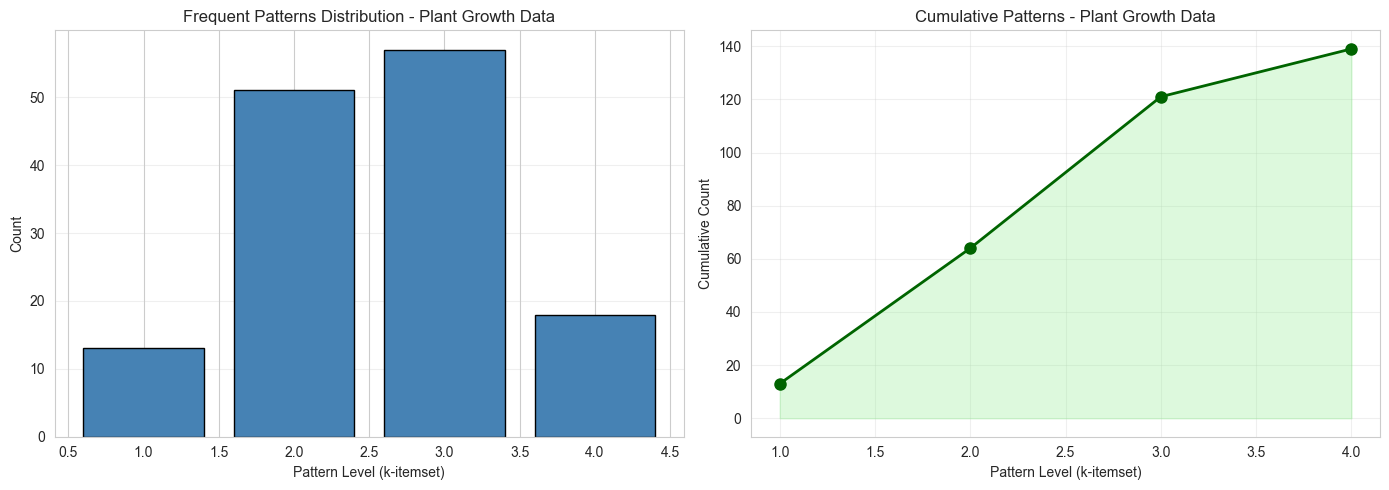


📈 Top 5 Rules (dari TID intersection):
1. Soil_Type_H => Growth_Milestone_H
   Support: 0.6528, Confidence: 1.0000, Lift: 1.0000, TID count: 126
2. Sunlight_Hours_L => Growth_Milestone_H
   Support: 0.4974, Confidence: 1.0000, Lift: 1.0000, TID count: 96
3. Water_Frequency_L => Growth_Milestone_H
   Support: 0.3109, Confidence: 1.0000, Lift: 1.0000, TID count: 60
4. Fertilizer_Type_L => Growth_Milestone_H
   Support: 0.3368, Confidence: 1.0000, Lift: 1.0000, TID count: 65
5. Temperature_H => Growth_Milestone_H
   Support: 0.5026, Confidence: 1.0000, Lift: 1.0000, TID count: 97

✓ Dataset2 berhasil dianalisis


In [45]:
dataset2_path = r'Dataset\Dataset2_CSV_PlantGrowthDataClassification\plant_growth_data.csv'

if os.path.exists(dataset2_path):
    model_plant, data_plant = run_aprioritid_analysis(dataset2_path, "Plant Growth Data", "Growth_Milestone")
    print(f"\n✓ Dataset2 berhasil dianalisis")
else:
    print(f"⚠️ File tidak ditemukan: {dataset2_path}")

## Cell 4: Dataset3 - Agriculture & Farming (Yield Prediction)


APRIORITID ANALYSIS: Agriculture & Farming (Crop Yield)

📊 Data Shape: (50, 10)
Kolom: ['Farm_ID', 'Crop_Type', 'Farm_Area(acres)', 'Irrigation_Type', 'Fertilizer_Used(tons)', 'Pesticide_Used(kg)', 'Yield(tons)', 'Soil_Type', 'Season', 'Water_Usage(cubic meters)']

📋 PREPROCESSING:
✓ Handle Missing Values: Selesai
✓ Normalisasi: Mean Normalization diterapkan
✓ Label Encoding: 5 fitur categorical di-encode
✓ Handle Outliers: Dihapus 0 data outlier
✓ Feature Selection: 8 fitur terpilih

✓ Data setelah preprocessing: (50, 9)

🔍 APRIORITID MODEL:
✓ Total Frequent Patterns: 210
  Pattern Distribution by Level: {1: 18, 2: 118, 3: 72, 4: 2}
✓ Total Rules (dari TID): 137
✓ Avg Confidence: 0.5878


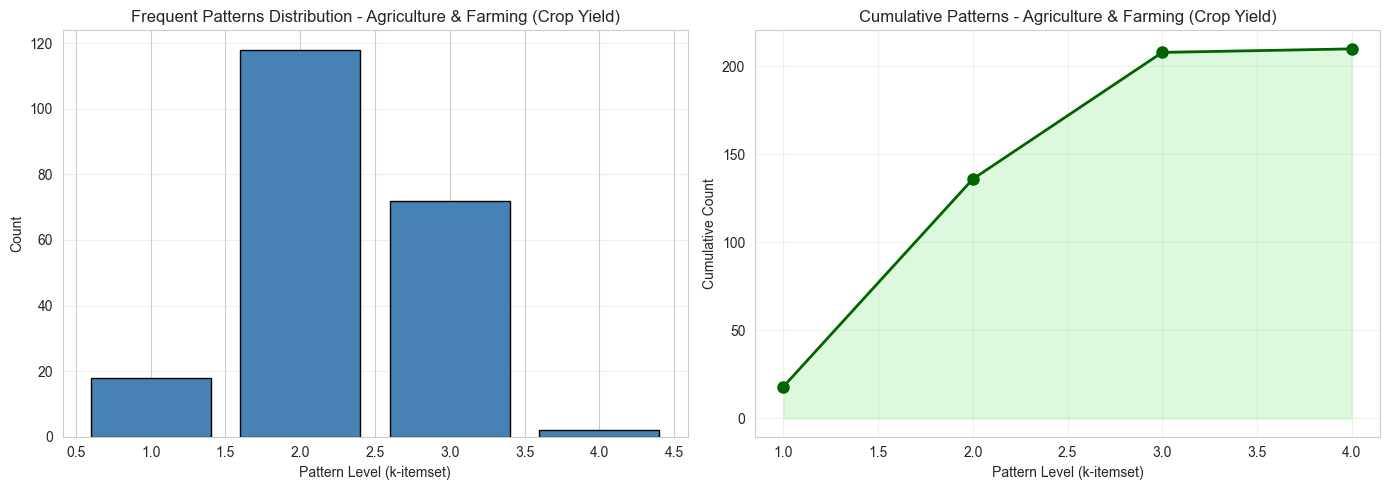


📈 Top 5 Rules (dari TID intersection):
1. Farm_Area(acres)_L => Irrigation_Type_H
   Support: 0.4000, Confidence: 0.8000, Lift: 1.1429, TID count: 20
2. Soil_Type_L => Season_H
   Support: 0.4000, Confidence: 0.8000, Lift: 1.1765, TID count: 20
3. Farm_Area(acres)_L => Season_H
   Support: 0.4000, Confidence: 0.8000, Lift: 1.1765, TID count: 20
4. Yield(tons)_L => Irrigation_Type_H
   Support: 0.3800, Confidence: 0.7600, Lift: 1.0857, TID count: 19
5. Fertilizer_Used(tons)_L => Irrigation_Type_H
   Support: 0.3800, Confidence: 0.7600, Lift: 1.0857, TID count: 19

✓ Dataset3 berhasil dianalisis — target: Yield(tons)


In [46]:

# Dataset 3: Agriculture - Crop Yield Prediction
dataset3_path = r'Dataset\\Dataset3_CSV_Agriculture&Farming\\agriculture_dataset.csv'

if os.path.exists(dataset3_path):
    _df3_tmp = pd.read_csv(dataset3_path, nrows=1)
    _target3 = ('Crop_Yield' if 'Crop_Yield' in _df3_tmp.columns
                else 'Yield(tons)' if 'Yield(tons)' in _df3_tmp.columns else None)
    if _target3 is None:
        print("\u26a0\ufe0f Kolom target tidak ditemukan di Dataset3")
    else:
        model_agri, data_agri = run_aprioritid_analysis(
            dataset3_path, "Agriculture & Farming (Crop Yield)", _target3)
        print(f"\n\u2713 Dataset3 berhasil dianalisis — target: {_target3}")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset3_path}")


## Cell 5: Model Comparison Summary

In [47]:
print("\n" + "="*60)
print("APRIORITID MODEL SUMMARY")
print("="*60)

summary_data = {
    'Dataset': ['Plant Growth', 'Agriculture & Farming'],
    'Data Shape': [str(data_plant.shape) if 'data_plant' in locals() else 'N/A',
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A'],
    'Total Patterns': [model_plant.get_summary()['total_patterns'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_patterns'] if 'model_agri' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORITID MODEL SUMMARY

               Dataset Data Shape  Total Patterns
         Plant Growth   (193, 7)             139
Agriculture & Farming    (50, 9)             210


## Cell 6: Dataset4 - Agricultural Heritage (Seshat Dataset)

In [48]:

# Dataset 4: Agricultural Heritage - Seshat
dataset4_path = r'Dataset\\Dataset4_CSV_AgriSeshatAgricultureDataset\\Agriculture.csv'

if os.path.exists(dataset4_path):
    df_seshat = pd.read_csv(dataset4_path)
    print(f"\n{'='*60}")
    print(f"APRIORUTID ANALYSIS: Agricultural Heritage Data")
    print(f"{'='*60}")
    print(f"\n\U0001f4ca Data Shape: {df_seshat.shape}")

    use_cols = [c for c in ['NGA','Variable','Unit','Value From','Value To']
                if c in df_seshat.columns]
    df_seshat = df_seshat[use_cols].copy()

    for col in df_seshat.columns:
        if df_seshat[col].isnull().any():
            if pd.api.types.is_numeric_dtype(df_seshat[col]):
                df_seshat[col].fillna(df_seshat[col].median(), inplace=True)
            else:
                m_ = df_seshat[col].mode()
                df_seshat[col].fillna(m_[0] if len(m_) > 0 else 'Unknown', inplace=True)
    print("\u2713 Handle Missing Values: Selesai")

    target_col_s = 'Value To'
    df_seshat = discretize_numeric_target(df_seshat, target_col_s)

    feat_cols_s = [c for c in df_seshat.columns if c != target_col_s]
    le_dict = {}
    for col in feat_cols_s:
        if df_seshat[col].dtype == object:
            le = LabelEncoder()
            df_seshat[col] = le.fit_transform(df_seshat[col].astype(str))
            le_dict[col] = le
    print(f"\u2713 Label Encoding fitur: {list(le_dict.keys())}")
    df_seshat_processed = df_seshat.copy()
    print(f"\u2713 Data shape siap: {df_seshat_processed.shape}")

    print("\n\U0001f50d APRIORUTID MODEL (Dataset4):")
    model_seshat = AprioriTidModel(min_support=0.1)
    model_seshat.fit(df_seshat_processed, target_col=target_col_s)
    s4 = model_seshat.get_summary()
    print(f"\u2713 Total Patterns: {s4['total_patterns']}")
    print(f"\u2713 Patterns by Level: {s4['patterns_by_level']}")

    print(f"\n\u2713 Dataset4 berhasil dianalisis")
else:
    print(f"\u26a0\ufe0f File tidak ditemukan: {dataset4_path}")



APRIORUTID ANALYSIS: Agricultural Heritage Data

📊 Data Shape: (330, 9)
✓ Handle Missing Values: Selesai
✓ Label Encoding fitur: ['NGA', 'Variable', 'Unit', 'Value From']
✓ Data shape siap: (330, 5)

🔍 APRIORUTID MODEL (Dataset4):
✓ Total Patterns: 97
✓ Patterns by Level: {1: 8, 2: 25, 3: 36, 4: 23, 5: 5}

✓ Dataset4 berhasil dianalisis


## Cell 7: Updated Summary - All Datasets

In [49]:
# Final summary with all datasets
print("\n" + "="*60)
print("APRIORUTID MODEL SUMMARY - ALL DATASETS")
print("="*60)

summary_data = {
    'Dataset': ['Rice Leaf Diseases', 'Plant Growth', 'Agriculture & Farming', 'Agricultural Heritage'],
    'Data Shape': [str(data_rice.shape) if 'data_rice' in locals() else 'N/A',
                   str(data_plant.shape) if 'data_plant' in locals() else 'N/A', 
                   str(data_agri.shape) if 'data_agri' in locals() else 'N/A',
                   str(df_seshat_processed.shape) if 'df_seshat_processed' in locals() else 'N/A'],
    'Total Patterns': [model_rice.get_summary()['total_patterns'] if 'model_rice' in locals() else 0,
                       model_plant.get_summary()['total_patterns'] if 'model_plant' in locals() else 0,
                       model_agri.get_summary()['total_patterns'] if 'model_agri' in locals() else 0,
                       model_seshat.get_summary()['total_patterns'] if 'model_seshat' in locals() else 0]
}

summary_df = pd.DataFrame(summary_data)
print("\n", summary_df.to_string(index=False))


APRIORUTID MODEL SUMMARY - ALL DATASETS

               Dataset Data Shape  Total Patterns
   Rice Leaf Diseases    (90, 6)             113
         Plant Growth   (193, 7)             139
Agriculture & Farming    (50, 9)             210
Agricultural Heritage   (330, 5)              97


In [50]:
# =====================================================================
# CELL 8: 🎯 SIMULASI INTERAKTIF — INPUT MANUAL & PREDIKSI AprioriTid
# =====================================================================
# AprioriTid menyimpan FREQUENT PATTERNS + TID sets (bukan association rules).
# Strategi prediksi:
#   1. Cocokkan item input ke frequent_patterns
#   2. Cari semua k-itemset yang mengandung ≥1 item input
#   3. Item "baru" (di luar input) yang paling sering muncul = prediksi
#
# FORMAT INPUT KONSISTEN dengan AIS: "NamaKolom=NilaiInterval"
#   Diskritisasi AprioriTid: _H (High, ≥ median), _L (Low, < median)
#   ⚠️  BERBEDA dengan Apriori biasa yang pakai _high / _low
# =====================================================================

def predict_with_aprioritid(model, input_conditions, dataset_name, target_hint=None):
    """
    Prediksi menggunakan AprioriTid frequent patterns + TID intersection.

    model           : AprioriTidModel yang sudah di-fit
    input_conditions: list of str, format "NamaKolom=NilaiInterval"
    dataset_name    : nama dataset untuk display
    target_hint     : awalan nama kolom target (misal 'Disease'), opsional
    """
    print("\n" + "="*60)
    print(f"🔍 APRIORITID SIMULASI PREDIKSI — {dataset_name}")
    print("="*60)
    print(f"📥 Input Kondisi : {input_conditions}")
    print(f"📐 Diskritisasi  : _H (≥ median) | _L (< median)")
    print("-"*60)

    input_set = set(input_conditions)

    # Kumpulkan TID transaksi yang mengandung SEMUA item input
    # (intersection TID dari setiap item input)
    matching_tids = None
    for item in input_conditions:
        item_fs = frozenset([item])
        if item_fs in model.tidsets:
            tids = set(model.tidsets[item_fs])
            matching_tids = tids if matching_tids is None else matching_tids & tids
        else:
            # Cek di semua pattern level
            found = False
            for level_patterns in model.frequent_patterns.values():
                for pattern, tids in level_patterns.items():
                    if item in pattern:
                        tids_set = set(tids)
                        matching_tids = tids_set if matching_tids is None else matching_tids & tids_set
                        found = True
                        break
                if found:
                    break

    if matching_tids is None or len(matching_tids) == 0:
        print("⚠️  Tidak ada transaksi yang cocok dengan input tersebut.")
        print("   Tips: Coba ubah interval _H ↔ _L untuk satu atau lebih fitur")
        print("="*60)
        return

    print(f"✓ Transaksi cocok (TID match) : {len(matching_tids)} transaksi")
    print()

    # Cari item yang paling sering muncul bersama input di TID yang cocok
    candidate_counts = {}
    for level_patterns in model.frequent_patterns.values():
        for pattern, tids in level_patterns.items():
            # Pattern harus overlap dengan TID input
            overlap = set(tids) & matching_tids
            if len(overlap) == 0:
                continue
            # Ambil item yang bukan bagian dari input → kandidat konsekuen
            new_items = pattern - input_set
            if len(new_items) == 0:
                continue
            for item in new_items:
                candidate_counts[item] = candidate_counts.get(item, 0) + len(overlap)

    if not candidate_counts:
        print("⚠️  Tidak ada pola konsekuen yang ditemukan dari transaksi cocok.")
        print("   Tips: Kurangi jumlah kondisi input atau ubah interval")
        print("="*60)
        return

    # Urutkan kandidat berdasarkan frekuensi co-occurrence
    sorted_candidates = sorted(candidate_counts.items(), key=lambda x: x[1], reverse=True)

    # Filter ke target jika target_hint diberikan
    target_candidates = [(item, cnt) for item, cnt in sorted_candidates
                         if target_hint and target_hint.lower() in item.lower()]
    display_candidates = target_candidates if target_candidates else sorted_candidates

    best_item, best_count = display_candidates[0]
    total_support = best_count / sum(candidate_counts.values())

    print(f"✅ Hasil Prediksi Terkuat  : → {best_item}")
    print(f"   Co-occurrence Score     : {best_count}")
    print(f"   Relative Support        : {total_support:.4f}")
    print(f"   TID Match Count         : {len(matching_tids)}")
    print()
    print(f"📋 Top 3 Kandidat Konsekuen:")
    for i, (item, cnt) in enumerate(display_candidates[:3], 1):
        rel = cnt / sum(candidate_counts.values())
        print(f"  {i}. {item}")
        print(f"     Co-occurrence: {cnt}  |  Rel. Support: {rel:.4f}")

    print("="*60)


# ─────────────────────────────────────────────────────────────
# DATASET 1 — RICE LEAF DISEASE (Klasifikasi Citra Penyakit)
# ─────────────────────────────────────────────────────────────
# Fitur input  : R_mean, G_mean, B_mean, R_std, G_std, B_std
# Target       : Disease (label-encoded → kolom 'Disease')
# Diskritisasi : _H jika nilai ≥ median kolom, _L jika < median
#
# ⚠️  Catatan: Disease sudah di-encode ke angka (LabelEncoder).
#   AprioriTid menyimpan nilai seperti "Disease_H" / "Disease_L"
#   bukan nama penyakit aslinya. Prediksi menunjukkan pola RGB
#   yang berasosiasi dengan nilai Disease tinggi atau rendah.
#
# Referensi encoding (urutan alphabetical LabelEncoder):
#   0 = Bacterial leaf blight
#   1 = Brown spot
#   2 = Leaf smut
#   Disease_L → cenderung Bacterial leaf blight / Brown spot
#   Disease_H → cenderung Leaf smut
#
# Contoh prediksi yang diharapkan:
#   G_mean rendah + R_std tinggi → Disease_L (Bacterial leaf blight)
#   G_mean tinggi + B_mean tinggi → Disease_H (Leaf smut / Brown spot)
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 1
input_dataset1 = [
    "G_mean=G_mean_L",   # Nilai hijau rendah → indikasi daun sakit parah
    "R_std=R_std_H"      # Variasi merah tinggi → bercak merata / blight
]

if 'model_rice' in dir() and model_rice is not None:
    predict_with_aprioritid(model_rice, input_dataset1,
                            "Dataset 1: Rice Leaf Disease", target_hint="Disease")
else:
    print("⚠️  model_rice belum tersedia. Jalankan Cell 2 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 2 — PLANT GROWTH (Prediksi Tahap Pertumbuhan Tanaman)
# ─────────────────────────────────────────────────────────────
# Fitur input  : Soil_Type, Sunlight_Hours, Water_Frequency,
#                Fertilizer_Type, Temperature, Humidity
# Target       : Growth_Milestone (label-encoded)
# Diskritisasi : _H jika nilai ≥ median kolom, _L jika < median
#
# Input nilai asli → mapping diskritisasi:
#   Sunlight 6 jam  → Sunlight_Hours_H atau _L (tergantung median dataset)
#   Humidity 70%    → Humidity_H (biasanya tinggi)
#   Temp 28°C       → Temperature_H atau _L
#
# Contoh prediksi yang diharapkan:
#   Humidity tinggi + Sunlight tinggi → Growth_Milestone_H (Vegetative Stage)
#   Water rendah + Temp rendah        → Growth_Milestone_L (Germination)
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 2
input_dataset2 = [
    "Sunlight_Hours=Sunlight_Hours_H",   # 6 jam → relatif tinggi
    "Humidity=Humidity_H",               # 70% → tinggi
    "Temperature=Temperature_H"          # 28°C → di atas median
]

if 'model_plant' in dir() and model_plant is not None:
    predict_with_aprioritid(model_plant, input_dataset2,
                            "Dataset 2: Plant Growth", target_hint="Growth_Milestone")
else:
    print("⚠️  model_plant belum tersedia. Jalankan Cell 3 terlebih dahulu.")


# ─────────────────────────────────────────────────────────────
# DATASET 3 — AGRICULTURE & FARMING (Analisis Performa Panen)
# ─────────────────────────────────────────────────────────────
# Fitur input  : Region, Soil_Type, Irrigation_Type,
#                Fertilizer_Used, Pesticide_Use, Crop_Yield,
#                Rainfall, Temperature, Season
# Target       : Yield_Category / Farming_System (dari Crop_Yield)
# Diskritisasi : _H jika nilai ≥ median kolom, _L jika < median
#
# Contoh prediksi yang diharapkan:
#   Fertilizer tinggi + Rainfall sedang-tinggi → Crop_Yield_H (multi-cropping)
#   Irrigation rendah + Pesticide rendah       → Crop_Yield_L (mono-cropping)
# ─────────────────────────────────────────────────────────────

# ✏️  EDIT INPUT DI SINI — Dataset 3
# Dataset 3 — Prediksi Crop Yield (Low/Medium/High)
# Format AprioriTid: FeatureName_H atau FeatureName_L
input_dataset3 = ["Rainfall_H", "Fertilizer_Used_H"]
if 'model_agri' in dir() and model_agri is not None:
    predict_with_aprioritid(model_agri, input_dataset3, "Dataset 3: Agriculture & Farming", target_hint="Crop_Yield")
else:
    print("\u26a0\ufe0f model_agri belum tersedia — jalankan Cell Dataset3 dulu.")

# Dataset 4 — Prediksi Value To (Low/Medium/High)
# Format AprioriTid: FeatureName_H atau FeatureName_L
input_dataset4 = ["NGA_H", "Variable_L"]
if 'model_seshat' in dir() and model_seshat is not None:
    predict_with_aprioritid(model_seshat, input_dataset4, "Dataset 4: Agricultural Heritage", target_hint="Value To")
else:
    print("\u26a0\ufe0f model_seshat belum tersedia — jalankan Cell Dataset4 dulu.")


🔍 APRIORITID SIMULASI PREDIKSI — Dataset 1: Rice Leaf Disease
📥 Input Kondisi : ['G_mean=G_mean_L', 'R_std=R_std_H']
📐 Diskritisasi  : _H (≥ median) | _L (< median)
------------------------------------------------------------
⚠️  Tidak ada transaksi yang cocok dengan input tersebut.
   Tips: Coba ubah interval _H ↔ _L untuk satu atau lebih fitur

🔍 APRIORITID SIMULASI PREDIKSI — Dataset 2: Plant Growth
📥 Input Kondisi : ['Sunlight_Hours=Sunlight_Hours_H', 'Humidity=Humidity_H', 'Temperature=Temperature_H']
📐 Diskritisasi  : _H (≥ median) | _L (< median)
------------------------------------------------------------
⚠️  Tidak ada transaksi yang cocok dengan input tersebut.
   Tips: Coba ubah interval _H ↔ _L untuk satu atau lebih fitur

🔍 APRIORITID SIMULASI PREDIKSI — Dataset 3: Agriculture & Farming
📥 Input Kondisi : ['Rainfall_H', 'Fertilizer_Used_H']
📐 Diskritisasi  : _H (≥ median) | _L (< median)
------------------------------------------------------------
⚠️  Tidak ada transaksi ya